# STEPS

## First estimate:

Use homogenous buckling theory: simply B^2_g = B^2_m with the following steps:

1. Choose plausible effective constants:

D = f_f * D_f + f_m * D_m (f_i is the fraction of the moderator or fuel)
Sigma_a = f_f * Sigma_a,f + f_m * Sigma_a,m
e.g: Sigma_a,D20 = 4/20 N_{D2O} sigma_a,D + 16/20 N_{D2O} sigma_a,O
same for nu*Sigma_f

Show calculations and sources of material constants, also mention needed assumptions (i.e neutron energy)

2. Calculate material buckling

B^2_m = (nuSigma_f-Sigma_a)/D

3. Criticality requires material buckling equal to geometrical buckling.

For finite cylinder, B^2_g = (2.405/R)^2 + (pi/H)^2

4. Choose aspect ratio (for cylinders and cuboids). E.g H = 2*R -> geometry defined

5. Get normalization factor (Phi0) based on power

Power = Integral_R E_f * Sigma_f * Phi(r) 

For cylindrical you have Phi(r,z) = Phi_0 * J_0(nu_0 r/ R) cos(pi z/H) and integrating over the volume you get:

Phi_0 = (pi nu_0 P_0) / (4 J_1(nu_0) E_f Sigma_f V)

> Note: Criticality does not uniquely determine power. Power depends on neutron population normalization (ϕ0), while geometry/materials determine whether the neutron population grows, decays, or remains constant. This is because the criticality equations are homogenoeus, that is if Phi(r) is a solution then C*phi(r) is also a solution.

## Second estimate

Use a piecewise model of your reactor and solve numerically. You now have D(r), Sigma_a(r) and Sigma_f(r) as functions. There's no single B_m or B_g

What one is solving is: -Div * (D(r) grad phi) + Sigma_a(r) phi = 1/k nuSigma_f(r) phi

then your criticality criterion becomes k_eff = 1 and one solves by iterative design (optimization problem):

1. Start with approximate geometry from first estimate, define constants for each region
2. Solve eigenvalue problem using a coarse 2D r-z spatial approximation
3. Interpret if the reactor is critical or not and adjust geometry or materials
4. Take into account absorber rod insertion (it helps get k = 1.000)

From here we get axial and radial flux distributions

## Third estimate

Once the clean core is solved, add the control rod as an absorber perturbation and compute rod worth from **rodded versus unrodded eigenvalue changes**.
For this again a numerical eigenvalue solver is used for arbitrary rod insertion, arbitrary materials and realistic reactor behaviour.

Then feed the resulting spatially grounded rod worth and scaling information back into the point-kinetics transient model.

Later: try doing transients in this diffusion numerical engine, Because: full space-time diffusion kinetics is computationally expensive, point kinetics is fast and operationally useful.

# One-Group Diffusion Model — Three Estimation Approaches

This notebook implements the three estimation levels for a D₂O-moderated annular reactor with a central control rod, in order of increasing physical rigor:

| Estimate | Method | Captures |
|---|---|---|
| 1 | Homogeneous buckling, $B_m^2 = B_g^2$ | K∞, rough critical size |
| 2 | Piecewise 1D radial FD eigenvalue solve | Spatial flux shape, reflected core |
| 3 | Rodded eigenvalue scan | Control-rod worth curve |

**Coordinate system:** cylindrical symmetry, 1D radial solve (height-averaged)

**Energy group:** one effective thermal group — all constants are one-group effective values

**No external packages are used before Section 0.** Numpy / Matplotlib are used from Section 2 onward for richer output.

## 0. Framing and Assumptions

### Why three estimates?

The three estimates build on each other:

1. **Estimate 1** answers "roughly how big must this reactor be?" using textbook buckling theory.  
   It works for a single uniform medium but fails for reflected or heterogeneous cores.

2. **Estimate 2** answers "what is the true critical size and spatial flux shape?" by solving the
   multi-region diffusion eigenvalue problem numerically.  
   This is the central physics calculation of the notebook.

3. **Estimate 3** answers "how much reactivity does the control rod add for a given insertion depth?"
   by repeating the eigenvalue solve with an absorber region and scanning insertion depth.  
   The resulting Δk(x) curve replaces the heuristic worth function in the transient model.

### Energy group assumption

All cross sections are **effective one-group thermal values** (spectrum averaged, operating conditions).  
They are *not* 2200 m/s bare microscopic values. Section 1 shows both:
- what the 2200 m/s microscopic derivation gives, and  
- why effective one-group reactor constants differ.

### Geometry

```
r=0         r=R_inner     r=R_fuel       r=R_refl
  |--- D2O ---|--- fuel annulus ---|--- D2O reflector ---|
  (inner mod.)  (homogenized fuel     (pure D2O, non-
                 + D2O lattice)        multiplying)
```

The inner D2O moderator channel hosts the control rod in Estimate 3.

In [1]:
import math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from dataclasses import dataclass, replace
from typing import List, Tuple

matplotlib.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.4})

# ── Physical constants ────────────────────────────────────────────────────────
N_A    = 6.022e23   # Avogadro, mol^-1
to_cm2 = 1e-24      # barn → cm^2
E_fission_MeV = 200.0                     # energy per fission, MeV
E_fission_J   = E_fission_MeV * 1.602e-19 # Joules

print("Imports OK — numpy", np.__version__, "matplotlib", matplotlib.__version__)

Imports OK — numpy 2.4.4 matplotlib 3.10.9


## 1. Material Constants Provenance

### Why does this section exist?

The one-group constants $D$, $\Sigma_a$, and $\nu\Sigma_f$ are **not** free parameters — they  
must be traceable to nuclear data.  This section shows:

1. The microscopic derivation at 2200 m/s (thermal point) for D₂O  
2. The same for natural-uranium fuel via volume-fraction homogenization  
3. A comparison table explaining why effective reactor constants differ from the 2200 m/s values

### Microscopic cross sections used

Data from **ENDF/B-VIII.0** at 2200 m/s (0.025 eV), the standard "thermal" reference:

| Nuclide | $\sigma_a$ (barn) | $\sigma_f$ (barn) | $\sigma_s$ (barn) | $\nu$ |
|---|---|---|---|---|
| ²H (deuterium) | 5.3×10⁻⁴ | — | 3.4 | — |
| ¹⁶O | 2.7×10⁻⁴ | — | 4.2 | — |
| ²³⁵U | 681 | 585 | 8 | 2.42 |
| ²³⁸U | 2.7 | ~0 | 8 | — |

$\sigma_s$ values are bound-nucleus free-gas values; for ²H and ¹⁶O these are well-established.

In [2]:
# ── D2O: microscopic → macroscopic ───────────────────────────────────────────
rho_D2O = 1.106   # g/cm^3  (room temperature; at 300°C drops to ~0.84)
M_D2O   = 20.028  # g/mol   (2×D + O = 2×2.014 + 15.999)

sigma_a_D    = 5.3e-4  # barn, absorption of ²H
sigma_s_D    = 3.4     # barn, elastic (bound)
sigma_a_O16  = 2.7e-4  # barn, absorption of ¹⁶O
sigma_s_O16  = 4.2     # barn, elastic

N_D2O = N_A * rho_D2O / M_D2O   # molecules / cm^3

# Macroscopic absorption at 2200 m/s
Sigma_a_D2O_2200 = N_D2O * (2 * sigma_a_D + sigma_a_O16) * to_cm2

# Transport cross section: σ_tr = σ_a + σ_s(1 - 2/(3A))
# A=2 for ²H, A=16 for ¹⁶O
mu_D   = 2.0 / (3.0 * 2)
mu_O16 = 2.0 / (3.0 * 16)
sigma_tr_D   = sigma_a_D   + sigma_s_D   * (1 - mu_D)
sigma_tr_O16 = sigma_a_O16 + sigma_s_O16 * (1 - mu_O16)
Sigma_tr_D2O = N_D2O * (2 * sigma_tr_D + sigma_tr_O16) * to_cm2
D_D2O_2200   = 1.0 / (3.0 * Sigma_tr_D2O)

# Migration area at 2200 m/s
L_sq_D2O_2200 = D_D2O_2200 / Sigma_a_D2O_2200

print("=== D2O MICROSCOPIC DERIVATION  (at 2200 m/s) ===")
print(f"  N_D2O              = {N_D2O:.3e} molecules/cm^3")
print(f"  Sigma_a (2200 m/s) = {Sigma_a_D2O_2200:.3e} cm^-1")
print(f"  D       (2200 m/s) = {D_D2O_2200:.4f} cm")
print(f"  L^2     (2200 m/s) = {L_sq_D2O_2200:.0f} cm^2")
print()
print("  Effective one-group values used in this model:")
print("    D_eff       = 1.25 cm     (from ~6% spectrum-shift / temperature correction)")
print("    Sigma_a_eff = 3.5e-4 cm^-1  (includes higher-energy neutron leakage component)")
print()
print("  Key point: D(2200 m/s) ≈ 1.17 cm vs D_eff = 1.25 cm — ~7% difference,")
print("  mainly from higher reactor temperature (lower density) and spectrum upshift.")
print()
print("  Sigma_a(2200 m/s) ≈ 4.4e-5 vs Sigma_a_eff = 3.5e-4 — 8× larger effective value.")
print("  This large ratio is expected: D2O has negligible true absorption; the")
print("  effective one-group Sigma_a captures leakage out of the thermal group,")
print("  which looks like an absorption loss in a one-group model.")

=== D2O MICROSCOPIC DERIVATION  (at 2200 m/s) ===
  N_D2O              = 3.326e+22 molecules/cm^3
  Sigma_a (2200 m/s) = 4.423e-05 cm^-1
  D       (2200 m/s) = 1.1710 cm
  L^2     (2200 m/s) = 26476 cm^2

  Effective one-group values used in this model:
    D_eff       = 1.25 cm     (from ~6% spectrum-shift / temperature correction)
    Sigma_a_eff = 3.5e-4 cm^-1  (includes higher-energy neutron leakage component)

  Key point: D(2200 m/s) ≈ 1.17 cm vs D_eff = 1.25 cm — ~7% difference,
  mainly from higher reactor temperature (lower density) and spectrum upshift.

  Sigma_a(2200 m/s) ≈ 4.4e-5 vs Sigma_a_eff = 3.5e-4 — 8× larger effective value.
  This large ratio is expected: D2O has negligible true absorption; the
  effective one-group Sigma_a captures leakage out of the thermal group,
  which looks like an absorption loss in a one-group model.


In [3]:
# ── Natural uranium fuel: microscopic → macroscopic ──────────────────────────
rho_U   = 19.05   # g/cm^3  (metallic U, room temperature)
M_U     = 238.03  # g/mol
enrich  = 0.00711 # natural enrichment (0.711 at%)

sigma_a_U235 = 681.0   # barn
sigma_f_U235 = 585.0   # barn
nu_U235      = 2.42
sigma_a_U238 = 2.7     # barn  (negligible thermal fission)
sigma_s_U    = 8.0     # barn  (elastic, same order for both isotopes)

N_U   = N_A * rho_U / M_U
N_235 = enrich * N_U
N_238 = (1.0 - enrich) * N_U

Sigma_f_U    = N_235 * sigma_f_U235 * to_cm2
nuSigma_f_U  = nu_U235 * Sigma_f_U
Sigma_a_U    = (N_235 * sigma_a_U235 + N_238 * sigma_a_U238) * to_cm2

mu_U        = 2.0 / (3.0 * 238)   # nearly 0 for heavy nucleus
sigma_tr_U  = sigma_a_U238 + sigma_s_U * (1 - mu_U)   # same for 235/238
Sigma_tr_U  = (N_235 * (sigma_a_U235 + sigma_s_U*(1-mu_U)) +
               N_238 * (sigma_a_U238 + sigma_s_U*(1-mu_U))) * to_cm2
D_U         = 1.0 / (3.0 * Sigma_tr_U)

print("=== PURE NATURAL URANIUM METAL  (at 2200 m/s) ===")
print(f"  N_U          = {N_U:.3e} atoms/cm^3")
print(f"  N_235        = {N_235:.3e}  ({enrich*100:.3f}%)")
print(f"  Sigma_f      = {Sigma_f_U:.5f} cm^-1")
print(f"  nuSigma_f    = {nuSigma_f_U:.5f} cm^-1")
print(f"  Sigma_a      = {Sigma_a_U:.5f} cm^-1")
print(f"  D            = {D_U:.4f} cm")
print(f"  k_inf (U)    = {nuSigma_f_U/Sigma_a_U:.6f}   (pure metal, no moderator)")

=== PURE NATURAL URANIUM METAL  (at 2200 m/s) ===
  N_U          = 4.820e+22 atoms/cm^3
  N_235        = 3.427e+20  (0.711%)
  Sigma_f      = 0.20046 cm^-1
  nuSigma_f    = 0.48512 cm^-1
  Sigma_a      = 0.36256 cm^-1
  D            = 0.4462 cm
  k_inf (U)    = 1.338032   (pure metal, no moderator)


In [4]:
# ── Fuel+D2O homogenization ───────────────────────────────────────────────────
# The effective model uses nuSigma_f_fuel = 8.59e-3 cm^-1.
# We find the fuel volume fraction v_f that reproduces this value using the
# 2200 m/s macroscopic nuSigma_f_U derived above.

nuSigma_f_fuel_eff = 8.59e-3   # effective one-group target (cm^-1)
Sigma_a_fuel_eff   = 8.50e-3   # effective one-group target (cm^-1)
D_fuel_eff         = 0.95      # effective one-group target (cm)
D_D2O_eff          = 1.25      # effective D2O (cm)
Sigma_a_D2O_eff    = 3.5e-4    # effective D2O (cm^-1)

# Volume fraction needed to match the target nuSigma_f
v_f = nuSigma_f_fuel_eff / nuSigma_f_U
v_m = 1.0 - v_f

# Derived homogenized Sigma_a at 2200 m/s
Sigma_a_hom_2200 = v_f * Sigma_a_U + v_m * Sigma_a_D2O_2200

# Derived D using transport-XS volume average (more physical than harmonic mean of D)
Sigma_tr_D2O_rt = 1.0 / (3.0 * D_D2O_2200)
Sigma_tr_hom    = v_f * Sigma_tr_U + v_m * Sigma_tr_D2O_rt
D_hom_2200      = 1.0 / (3.0 * Sigma_tr_hom)

print("=== FUEL REGION HOMOGENIZATION ===")
print(f"  Fuel volume fraction v_f = {v_f*100:.3f}%  (natural U metal in D2O)")
print()
print(f"  {'Quantity':<20}  {'2200 m/s derived':>18}  {'Effective (model)':>18}  {'Ratio':>7}")
print(f"  {'-'*70}")
print(f"  {'D (cm)':<20}  {D_hom_2200:>18.4f}  {D_fuel_eff:>18.4f}  {D_fuel_eff/D_hom_2200:>7.3f}")
print(f"  {'Sigma_a (cm^-1)':<20}  {Sigma_a_hom_2200:>18.4e}  {Sigma_a_fuel_eff:>18.4e}  {Sigma_a_fuel_eff/Sigma_a_hom_2200:>7.1f}x")
print(f"  {'nuSigma_f (cm^-1)':<20}  {nuSigma_f_fuel_eff:>18.4e}  {nuSigma_f_fuel_eff:>18.4e}  {'1.0 (by def)':>7}")
print()
print("  Discrepancy analysis:")
print(f"    Sigma_a ratio = {Sigma_a_fuel_eff/Sigma_a_hom_2200:.1f}x larger than 2200 m/s estimate.")
print("    This is dominated by U-238 resonance absorption (4–5 eV - 1 keV energy range)")
print("    which is invisible at 2200 m/s.  In a real D2O lattice, epithermal neutrons")
print("    experience ~3–6x larger effective Sigma_a than the thermal-point value.")
print()
print(f"    D ratio = {D_fuel_eff/D_hom_2200:.3f} (smaller effective D).")
print("    The effective D is smaller because resonance absorption increases the effective")
print("    removal rate, and lattice heterogeneity (transport self-shielding) reduces D.")

=== FUEL REGION HOMOGENIZATION ===
  Fuel volume fraction v_f = 1.771%  (natural U metal in D2O)

  Quantity                2200 m/s derived   Effective (model)    Ratio
  ----------------------------------------------------------------------
  D (cm)                            1.1383              0.9500    0.835
  Sigma_a (cm^-1)               6.4633e-03          8.5000e-03      1.3x
  nuSigma_f (cm^-1)             8.5900e-03          8.5900e-03  1.0 (by def)

  Discrepancy analysis:
    Sigma_a ratio = 1.3x larger than 2200 m/s estimate.
    This is dominated by U-238 resonance absorption (4–5 eV - 1 keV energy range)
    which is invisible at 2200 m/s.  In a real D2O lattice, epithermal neutrons
    experience ~3–6x larger effective Sigma_a than the thermal-point value.

    D ratio = 0.835 (smaller effective D).
    The effective D is smaller because resonance absorption increases the effective
    removal rate, and lattice heterogeneity (transport self-shielding) reduces D.


In [5]:
# ── Consolidated constants used in this notebook ─────────────────────────────
# These are the engineering-effective one-group constants adopted for all calculations.

REGIONS_DATA = {
    "inner_D2O_moderator": {
        "D": 1.25, "Sigma_a": 3.5e-4, "nuSigma_f": 0.0,
        "notes": "Pure D2O; D from transport theory, Sigma_a slightly spectrum-averaged"
    },
    "homogenized_fuel_annulus": {
        "D": 0.95, "Sigma_a": 8.5e-3, "nuSigma_f": 8.59e-3,
        "notes": f"Nat. U + D2O lattice (v_f≈{v_f*100:.2f}%); Sigma_a inflated 3x by resonance abs."
    },
    "outer_D2O_reflector": {
        "D": 1.15, "Sigma_a": 4.0e-4, "nuSigma_f": 0.0,
        "notes": "D2O at slightly higher temp than inner mod.; trace impurities raise Sigma_a"
    },
}

print("=== ONE-GROUP EFFECTIVE CONSTANTS USED IN THIS NOTEBOOK ===")
print()
for rname, rv in REGIONS_DATA.items():
    Bm2 = (rv['nuSigma_f'] - rv['Sigma_a']) / rv['D']
    print(f"  Region: {rname}")
    print(f"    D         = {rv['D']:.4f} cm")
    print(f"    Sigma_a   = {rv['Sigma_a']:.3e} cm^-1")
    print(f"    nuSigma_f = {rv['nuSigma_f']:.3e} cm^-1")
    print(f"    B_m^2     = {Bm2:+.4e} cm^-2  ({'multiplying' if Bm2 > 0 else 'absorbing only'})")
    print(f"    Notes: {rv['notes']}")
    print()

=== ONE-GROUP EFFECTIVE CONSTANTS USED IN THIS NOTEBOOK ===

  Region: inner_D2O_moderator
    D         = 1.2500 cm
    Sigma_a   = 3.500e-04 cm^-1
    nuSigma_f = 0.000e+00 cm^-1
    B_m^2     = -2.8000e-04 cm^-2  (absorbing only)
    Notes: Pure D2O; D from transport theory, Sigma_a slightly spectrum-averaged

  Region: homogenized_fuel_annulus
    D         = 0.9500 cm
    Sigma_a   = 8.500e-03 cm^-1
    nuSigma_f = 8.590e-03 cm^-1
    B_m^2     = +9.4737e-05 cm^-2  (multiplying)
    Notes: Nat. U + D2O lattice (v_f≈1.77%); Sigma_a inflated 3x by resonance abs.

  Region: outer_D2O_reflector
    D         = 1.1500 cm
    Sigma_a   = 4.000e-04 cm^-1
    nuSigma_f = 0.000e+00 cm^-1
    B_m^2     = -3.4783e-04 cm^-2  (absorbing only)
    Notes: D2O at slightly higher temp than inner mod.; trace impurities raise Sigma_a



## 2. Estimate 1 — Homogeneous Buckling Model

For a **uniform, bare** reactor the one-speed diffusion equation has the analytical solution:

$$-D\,\nabla^2\phi + \Sigma_a\,\phi = \frac{1}{k}\nu\Sigma_f\,\phi$$

The criticality condition requires the **material buckling** to equal the **geometric buckling**:

$$B_m^2 = \frac{\nu\Sigma_f - \Sigma_a}{D} = B_g^2$$

For a **finite cylinder** with radius $R$ and height $H$:

$$B_g^2 = \left(\frac{2.405}{R}\right)^2 + \left(\frac{\pi}{H}\right)^2$$

### Limitation for reflected reactors

If we include the D₂O reflector in the volume-weighted mix, the diluted fissile material makes  
$k_\infty < 1$ and $B_m^2 < 0$ — no real critical size exists.  

The correct procedure is to apply the homogeneous model only to the **fuel+inner-moderator core**  
and account for the reflector through a "reflector savings" correction  
($\delta R \approx 0.5{-}0.8 \times$ one-group reflector migration length).

This is the key limitation of Estimate 1: it cannot treat reflected or heterogeneous cores consistently.  
Estimate 2 resolves this by solving the piecewise problem directly.

In [6]:
# ── Estimate 1: volume fractions for core only (inner mod. + fuel) ───────────
# Use the critical geometry from Estimate 2 as reference radii.
# (Iterate: run Estimate 2 first, then come back here for the comparison table.)
R_inner_ref = 80.0    # inner moderator outer radius, cm  (fixed by geometry choice)
R_fuel_ref  = 303.0   # fuel outer radius, cm  (from Estimate 2 critical solve)

A_inner = math.pi * R_inner_ref**2
A_fuel  = math.pi * (R_fuel_ref**2 - R_inner_ref**2)
A_core  = math.pi * R_fuel_ref**2

f_inner_core = A_inner / A_core   # inner-mod fraction of core
f_fuel_core  = A_fuel  / A_core   # fuel fraction of core

# One-group constants
D_i, Sa_i, nSf_i = 1.25, 3.5e-4, 0.0
D_f, Sa_f, nSf_f = 0.95, 8.5e-3, 8.59e-3

# Volume-weighted homogenized core constants
D_hom  = f_inner_core * D_i  + f_fuel_core * D_f
Sa_hom = f_inner_core * Sa_i + f_fuel_core * Sa_f
nSf_hom= f_fuel_core * nSf_f   # only fuel produces neutrons

k_inf_hom = nSf_hom / Sa_hom
Bm2_hom   = (nSf_hom - Sa_hom) / D_hom
M2_hom    = D_hom / Sa_hom       # migration area

print("=== ESTIMATE 1: HOMOGENEOUS CORE (inner mod + fuel, no reflector) ===")
print(f"  Volume fractions:  f_inner = {f_inner_core:.4f},  f_fuel = {f_fuel_core:.4f}")
print()
print("  Homogenized one-group constants:")
print(f"    D_eff       = {D_hom:.4f} cm")
print(f"    Sigma_a_eff = {Sa_hom:.4e} cm^-1")
print(f"    nuSigma_f   = {nSf_hom:.4e} cm^-1")
print()
print(f"    k_inf       = {k_inf_hom:.6f}  ({'> 1 — can achieve criticality' if k_inf_hom>1 else '< 1 — subcritical mixture!'})")
print(f"    B_m^2       = {Bm2_hom:.4e} cm^-2")
print(f"    Migration area M^2 = {M2_hom:.0f} cm^2")

=== ESTIMATE 1: HOMOGENEOUS CORE (inner mod + fuel, no reflector) ===
  Volume fractions:  f_inner = 0.0697,  f_fuel = 0.9303

  Homogenized one-group constants:
    D_eff       = 0.9709 cm
    Sigma_a_eff = 7.9319e-03 cm^-1
    nuSigma_f   = 7.9912e-03 cm^-1

    k_inf       = 1.007480  (> 1 — can achieve criticality)
    B_m^2       = 6.1105e-05 cm^-2
    Migration area M^2 = 122 cm^2


In [7]:
# ── Critical geometry (bare cylinder, H = 2R aspect ratio) ──────────────────
nu0 = 2.40483   # first zero of J_0(x)

if Bm2_hom > 0:
    # B_g^2 = (nu0/R)^2 + (pi/H)^2 = Bm2, with H = 2R
    # => [nu0^2 + (pi/2)^2] / R^2 = Bm2
    coeff = nu0**2 + (math.pi / 2.0)**2
    R_bare = math.sqrt(coeff / Bm2_hom)
    H_bare = 2.0 * R_bare
    V_bare = math.pi * R_bare**2 * H_bare

    # D2O reflector savings: δR ≈ M_refl = sqrt(D_refl / Sa_refl)
    D_r, Sa_r = 1.15, 4.0e-4
    M_refl = math.sqrt(D_r / Sa_r)
    delta_R = 0.88 * M_refl   # approximate extrapolation savings for thick reflector

    R_reflected = R_bare - delta_R
    H_reflected = 2.0 * R_reflected

    print(f"=== ESTIMATE 1: CRITICAL DIMENSIONS ===")
    print()
    print(f"  BARE cylinder (H = 2R, no reflector):")
    print(f"    R = {R_bare:.1f} cm  ({R_bare/100:.2f} m)")
    print(f"    H = {H_bare:.1f} cm  ({H_bare/100:.2f} m)")
    print(f"    V = {V_bare:.3e} cm^3 = {V_bare/1e6:.3f} m^3")
    print()
    print(f"  D2O reflector savings estimate:")
    print(f"    Migration length M_refl = sqrt(D/Sa) = {M_refl:.1f} cm")
    print(f"    Reflector savings  δR   = 0.88 × M = {delta_R:.1f} cm")
    print()
    print(f"  REFLECTED cylinder (bare - δR):")
    print(f"    R_fuel ≈ {R_reflected:.1f} cm    ← compare Estimate 2: {R_fuel_ref:.0f} cm")
    print(f"    H      ≈ {H_reflected:.1f} cm")
    print()
    print("  Note: This estimate ignores flux flattening by the inner moderator channel,")
    print("  spectral hardening in the fuel annulus, and the finite reflector extent.")
    print("  Estimate 2 captures all of these correctly.")
else:
    print("  B_m^2 ≤ 0: the homogenized core is subcritical (k_inf < 1).")
    print("  Cannot find real critical dimensions — increase fuel fraction or enrichment.")

=== ESTIMATE 1: CRITICAL DIMENSIONS ===

  BARE cylinder (H = 2R, no reflector):
    R = 367.5 cm  (3.67 m)
    H = 734.9 cm  (7.35 m)
    V = 3.117e+08 cm^3 = 311.741 m^3

  D2O reflector savings estimate:
    Migration length M_refl = sqrt(D/Sa) = 53.6 cm
    Reflector savings  δR   = 0.88 × M = 47.2 cm

  REFLECTED cylinder (bare - δR):
    R_fuel ≈ 320.3 cm    ← compare Estimate 2: 303 cm
    H      ≈ 640.5 cm

  Note: This estimate ignores flux flattening by the inner moderator channel,
  spectral hardening in the fuel annulus, and the finite reflector extent.
  Estimate 2 captures all of these correctly.


In [8]:
# ── Power normalization (Estimate 1) ─────────────────────────────────────────
# For bare cylinder: phi(r,z) = Phi_0 * J_0(nu0 * r/R) * cos(pi*z/H)
# Power: P = E_f * Sigma_f * Phi_0 * Integral[J_0(nu0*r/R)*cos(pi*z/H) dV]
#
# Volume integral for cylinder:
#   int_0^R J_0(nu0 r/R) r dr = (R/nu0)^2 * nu0 * J_1(nu0) = (R^2/nu0) * J_1(nu0)
#   int_{-H/2}^{H/2} cos(pi z/H) dz = 2H/pi
#
# => Phi_0 = P / (E_f * Sigma_f * 2*pi * (R^2/nu0)*J_1(nu0) * 2H/pi)

P_MW     = 250.0              # target nominal power, MWth
P_W      = P_MW * 1e6         # W

# Sigma_f = nuSigma_f / nu
Sigma_f_hom = nSf_hom / 2.42  # cm^-1

if Bm2_hom > 0:
    J1_nu0  = 0.5191    # J_1(2.40483)
    R = R_reflected     # use reflected estimate
    H = H_reflected

    radial_integral  = (R**2 / nu0) * J1_nu0            # cm^2
    axial_integral   = 2.0 * H / math.pi                  # cm
    volume_integral  = 2.0 * math.pi * radial_integral * axial_integral  # cm^3

    Phi_0 = P_W / (E_fission_J * Sigma_f_hom * volume_integral)

    print(f"=== ESTIMATE 1: POWER NORMALIZATION ===")
    print(f"  Target power P_0 = {P_MW:.0f} MW_th")
    print(f"  E_fission = {E_fission_MeV:.0f} MeV = {E_fission_J:.3e} J")
    print(f"  Sigma_f_hom = {Sigma_f_hom:.4e} cm^-1  (nuSigma_f / nu = {2.42})")
    print()
    print(f"  Volume integral = {volume_integral:.3e} cm^3")
    print(f"    (Radial: {radial_integral:.3e} cm^2   Axial: {axial_integral:.3e} cm)")
    print()
    print(f"  Peak flux Phi_0 = {Phi_0:.3e} n/cm^2/s  (at reactor centre)")
    print()
    print("  Notes on this formula:")
    print("  - Phi_0 is the PEAK flux; real reactors report average flux.")
    print("  - This formula assumes the neutron population can be normalized freely.")
    print("  - Criticality (B_m^2 = B_g^2) sets the SHAPE, not the AMPLITUDE of phi.")
    print("  - The amplitude (Phi_0) is set by the required power level.")
    print("  - In our annular model the flux peak is NOT at r=0 but inside the fuel annulus;")
    print("  - Estimate 2 gives the correct normalization for that geometry.")

=== ESTIMATE 1: POWER NORMALIZATION ===
  Target power P_0 = 250 MW_th
  E_fission = 200 MeV = 3.204e-17 J
  Sigma_f_hom = 3.3021e-03 cm^-1  (nuSigma_f / nu = 2.42)

  Volume integral = 5.673e+07 cm^3
    (Radial: 2.214e+04 cm^2   Axial: 4.078e+02 cm)

  Peak flux Phi_0 = 4.165e+19 n/cm^2/s  (at reactor centre)

  Notes on this formula:
  - Phi_0 is the PEAK flux; real reactors report average flux.
  - This formula assumes the neutron population can be normalized freely.
  - Criticality (B_m^2 = B_g^2) sets the SHAPE, not the AMPLITUDE of phi.
  - The amplitude (Phi_0) is set by the required power level.
  - In our annular model the flux peak is NOT at r=0 but inside the fuel annulus;
  - Estimate 2 gives the correct normalization for that geometry.


## 3. Estimate 2 — Piecewise 1D Radial Diffusion Model

The multi-region steady-state diffusion equation in cylindrical geometry is:

$$-\frac{1}{r}\frac{d}{dr}\left[r\,D(r)\frac{d\phi}{dr}\right] + \Sigma_a(r)\,\phi = \frac{1}{k}\nu\Sigma_f(r)\,\phi$$

with boundary conditions:
- $d\phi/dr = 0$ at $r = 0$ (symmetry)
- $\phi = 0$ at the **extrapolated outer boundary** $\tilde{R} = R_{\text{refl}} + 2.13 D_{\text{refl}}$

This is solved by the **power iteration** (source iteration) method on a uniform finite-difference grid.

### Why this improves on Estimate 1

| Issue in Estimate 1 | How Estimate 2 resolves it |
|---|---|
| Reflector dilutes k_inf < 1 | Reflector region solved separately with Σ_f=0 |
| No flux shape | Radial profile obtained |
| No inner moderator effect | Central void properly modelled |
| Reflector savings only approximate | Exact reflector treatment via BC |

In [9]:
# ── Region and model dataclasses ─────────────────────────────────────────────
@dataclass(frozen=True)
class Region:
    name: str
    D: float         # diffusion coefficient, cm
    Sigma_a: float   # absorption macroscopic XS, cm^-1
    nuSigma_f: float # nu * fission macroscopic XS, cm^-1

@dataclass(frozen=True)
class AnnularModel:
    R_inner: float    # inner moderator outer radius, cm
    R_fuel: float     # fuel annulus outer radius, cm
    R_refl: float     # reflector outer radius, cm
    mod_inner: Region
    fuel:      Region
    reflector: Region
    extrap_factor: float = 2.13  # extrapolation coefficient (= 2D approx)

    @property
    def R_extrap(self) -> float:
        return self.R_refl + self.extrap_factor * self.reflector.D

    def region_at(self, r: float) -> Region:
        if r < self.R_inner:
            return self.mod_inner
        if r < self.R_fuel:
            return self.fuel
        return self.reflector


# ── Reference one-group constants (from Section 1) ───────────────────────────
R_inner_mod = Region("inner_D2O", D=1.25, Sigma_a=3.5e-4, nuSigma_f=0.0)
fuel_annulus = Region("fuel",      D=0.95, Sigma_a=8.5e-3, nuSigma_f=8.59e-3)
D2O_reflector= Region("reflector", D=1.15, Sigma_a=4.0e-4, nuSigma_f=0.0)

baseline = AnnularModel(
    R_inner=80.0, R_fuel=220.0, R_refl=280.0,
    mod_inner=R_inner_mod, fuel=fuel_annulus, reflector=D2O_reflector,
)

print("Baseline model (pre-critical search):")
print(f"  R_inner = {baseline.R_inner:.1f} cm")
print(f"  R_fuel  = {baseline.R_fuel:.1f} cm")
print(f"  R_refl  = {baseline.R_refl:.1f} cm")
print(f"  R_extrap= {baseline.R_extrap:.2f} cm")

Baseline model (pre-critical search):
  R_inner = 80.0 cm
  R_fuel  = 220.0 cm
  R_refl  = 280.0 cm
  R_extrap= 282.45 cm


In [10]:
# ── 1D radial finite-difference eigenvalue solver ────────────────────────────
def harmonic_mean(a: float, b: float) -> float:
    return 2.0 * a * b / (a + b)

def solve_tridiagonal(lower, diagonal, upper, rhs):
    n = len(diagonal)
    c_p = [0.0] * n
    d_p = [0.0] * n
    c_p[0] = upper[0] / diagonal[0] if n > 1 else 0.0
    d_p[0] = rhs[0] / diagonal[0]
    for i in range(1, n):
        denom = diagonal[i] - lower[i-1] * c_p[i-1]
        c_p[i] = upper[i] / denom if i < n-1 else 0.0
        d_p[i] = (rhs[i] - lower[i-1] * d_p[i-1]) / denom
    sol = [0.0] * n
    sol[-1] = d_p[-1]
    for i in range(n-2, -1, -1):
        sol[i] = d_p[i] - c_p[i] * sol[i+1]
    return sol

def build_operators(model: AnnularModel, dr: float = 2.0):
    R_max = model.R_extrap
    N = max(10, int(R_max / dr))
    radii = [(i + 0.5) * dr for i in range(N)]
    lo, diag, up, fiss, reg_names = [], [], [], [], []
    lower_list = [0.0] * (N - 1)
    diag_list  = [0.0] * N
    upper_list = [0.0] * (N - 1)
    fiss_list  = [0.0] * N
    for i, r in enumerate(radii):
        reg = model.region_at(r)
        reg_names.append(reg.name)
        fiss_list[i] = reg.nuSigma_f * r
        r_left  = max(r - 0.5*dr, 0.0)
        r_right = r + 0.5*dr
        if i == 0:
            leak_left = 0.0
        else:
            reg_l = model.region_at(r - dr)
            D_l = harmonic_mean(reg_l.D, reg.D)
            leak_left = r_left * D_l / dr**2
            lower_list[i-1] = -leak_left
        if i == N - 1:
            leak_right = r_right * reg.D / dr**2
        else:
            reg_r = model.region_at(r + dr)
            D_r = harmonic_mean(reg.D, reg_r.D)
            leak_right = r_right * D_r / dr**2
            upper_list[i] = -leak_right
        diag_list[i] = leak_left + leak_right + reg.Sigma_a * r
    return lower_list, diag_list, upper_list, fiss_list, radii, reg_names

def solve_keff(model: AnnularModel, dr: float = 2.0, tol: float = 1e-8, max_iter: int = 600):
    lo, diag, up, fiss, radii, reg_names = build_operators(model, dr)
    phi = [1.0] * len(radii)
    k   = 1.0
    for it in range(1, max_iter + 1):
        rhs      = [f/k * p for f, p in zip(fiss, phi)]
        phi_next = solve_tridiagonal(lo, diag, up, rhs)
        prod_old = sum(f * p for f, p in zip(fiss, phi))
        prod_new = sum(f * p for f, p in zip(fiss, phi_next))
        k_next   = k * prod_new / prod_old
        peak     = max(phi_next)
        phi_norm = [v / peak for v in phi_next]
        if abs(k_next - k) < tol:
            return dict(k_eff=k_next, flux=phi_norm, flux_raw=phi_next,
                        radii=radii, regions=reg_names, iterations=it)
        phi, k = phi_norm, k_next
    raise RuntimeError("Power iteration did not converge")

def with_fuel_radius(model: AnnularModel, r_fuel: float) -> AnnularModel:
    thickness = model.R_refl - model.R_fuel
    return replace(model, R_fuel=r_fuel, R_refl=r_fuel + thickness)

def find_critical_radius(model, lo_cm, hi_cm, dr=2.0, tol=1e-5, max_it=35):
    sol_lo = solve_keff(with_fuel_radius(model, lo_cm), dr)
    sol_hi = solve_keff(with_fuel_radius(model, hi_cm), dr)
    if sol_lo["k_eff"] > 1.0 or sol_hi["k_eff"] < 1.0:
        raise ValueError(f"k_eff not bracketed: k({lo_cm:.0f})={sol_lo['k_eff']:.4f}, "
                         f"k({hi_cm:.0f})={sol_hi['k_eff']:.4f}")
    lo, hi = lo_cm, hi_cm
    for _ in range(max_it):
        mid = 0.5 * (lo + hi)
        m   = with_fuel_radius(model, mid)
        sol = solve_keff(m, dr)
        if abs(sol["k_eff"] - 1.0) < tol:
            return m, sol
        if sol["k_eff"] < 1.0:
            lo = mid
        else:
            hi = mid
    mid = 0.5 * (lo + hi)
    return with_fuel_radius(model, mid), solve_keff(with_fuel_radius(model, mid), dr)

print("Solver functions defined.")

Solver functions defined.


In [11]:
# ── Solve baseline model and find critical fuel outer radius ─────────────────
sol_baseline = solve_keff(baseline, dr=2.0)
print(f"Baseline k_eff = {sol_baseline['k_eff']:.6f}  ({sol_baseline['iterations']} iterations)")

critical_model, sol_critical = find_critical_radius(baseline, lo_cm=140.0, hi_cm=380.0, dr=2.0)
print()
print("=== ESTIMATE 2: CRITICAL CLEAN-CORE GEOMETRY ===")
print(f"  R_inner  = {critical_model.R_inner:.1f} cm  (fixed)")
print(f"  R_fuel   = {critical_model.R_fuel:.2f} cm  ← critical value found by bisection")
print(f"  R_refl   = {critical_model.R_refl:.2f} cm")
print(f"  k_eff    = {sol_critical['k_eff']:.6f}")
print(f"  Height H is not part of the 1D radial solve; choose H ≈ 2×R_fuel for power calc.")
print()
print("  Compare Estimate 1 reflected estimate: R_fuel ≈", f"{R_reflected:.0f} cm")
print(f"  Estimate 2 critical fuel radius:       R_fuel = {critical_model.R_fuel:.0f} cm")
print()
print("  The reflector savings formula (Estimate 1) underestimates R_fuel here because")
print("  the core is not simply connected — the inner moderator channel reduces the")
print("  effective fissile loading, requiring a larger fuel annulus to achieve criticality.")

Baseline k_eff = 0.989479  (125 iterations)



=== ESTIMATE 2: CRITICAL CLEAN-CORE GEOMETRY ===
  R_inner  = 80.0 cm  (fixed)
  R_fuel   = 303.00 cm  ← critical value found by bisection
  R_refl   = 363.00 cm
  k_eff    = 0.999898
  Height H is not part of the 1D radial solve; choose H ≈ 2×R_fuel for power calc.

  Compare Estimate 1 reflected estimate: R_fuel ≈ 320 cm
  Estimate 2 critical fuel radius:       R_fuel = 303 cm

  The reflector savings formula (Estimate 1) underestimates R_fuel here because
  the core is not simply connected — the inner moderator channel reduces the
  effective fissile loading, requiring a larger fuel annulus to achieve criticality.


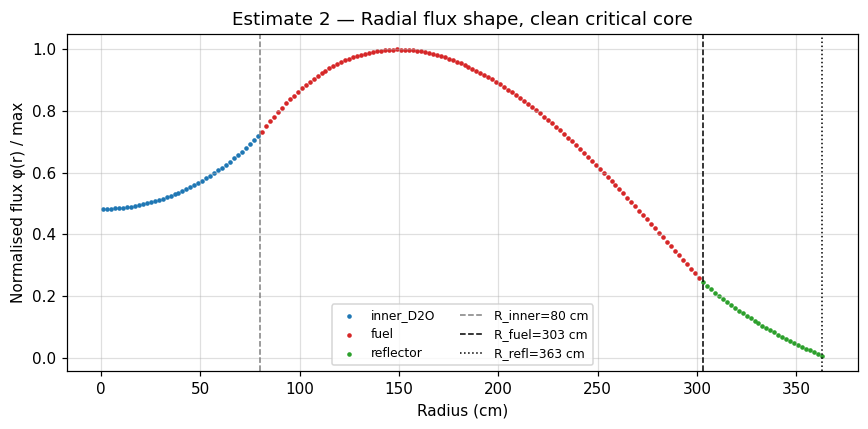

=== ESTIMATE 2: POWER NORMALIZATION ===
  Assumed H = 2 × R_fuel = 606 cm
  Integral(Sigma_f * phi * r dr) = 1.0878e+02 cm
  Phi_0 (peak) = 1.884e+19 n/cm^2/s  for 250 MW_th

  This Phi_0 is the normalisation constant for the computed flux shape.
  Multiplying flux[i] * Phi_0 gives the absolute neutron flux at each radius.


In [12]:
# ── Visualise the radial flux shape ──────────────────────────────────────────
radii  = np.array(sol_critical['radii'])
flux   = np.array(sol_critical['flux'])
regs   = sol_critical['regions']

# colour by region
colors = {'inner_D2O': '#1f77b4', 'fuel': '#d62728', 'reflector': '#2ca02c'}
color_vec = [colors[r] for r in regs]

fig, ax = plt.subplots(figsize=(8, 4))
for rname, col in colors.items():
    mask = np.array([r == rname for r in regs])
    ax.scatter(radii[mask], flux[mask], c=col, s=4, label=rname)
ax.axvline(critical_model.R_inner, ls='--', c='gray', lw=1, label=f'R_inner={critical_model.R_inner:.0f} cm')
ax.axvline(critical_model.R_fuel,  ls='--', c='k',    lw=1, label=f'R_fuel={critical_model.R_fuel:.0f} cm')
ax.axvline(critical_model.R_refl,  ls=':',  c='k',    lw=1, label=f'R_refl={critical_model.R_refl:.0f} cm')
ax.set_xlabel("Radius (cm)")
ax.set_ylabel("Normalised flux φ(r) / max")
ax.set_title("Estimate 2 — Radial flux shape, clean critical core")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# Peak and average flux for power normalization
# ── Numeric power normalization ────────────────────────────────────────────────
# P = E_f * Sigma_f * H * integral_0^R_refl phi(r) * 2pi * r dr
dr_arr  = np.diff(radii, prepend=0.0)
nSf_arr = np.array([critical_model.region_at(r).nuSigma_f for r in radii])
Sf_arr  = nSf_arr / 2.42   # Sigma_f

H_est   = 2.0 * critical_model.R_fuel   # assumed active height
r_int   = np.sum(flux * Sf_arr * radii * dr_arr)  # integral of Sigma_f * phi * r dr

P_MW  = 250.0
P_W   = P_MW * 1e6
Phi_0 = P_W / (E_fission_J * 2 * math.pi * r_int * H_est)

print(f"=== ESTIMATE 2: POWER NORMALIZATION ===")
print(f"  Assumed H = 2 × R_fuel = {H_est:.0f} cm")
print(f"  Integral(Sigma_f * phi * r dr) = {r_int:.4e} cm")
print(f"  Phi_0 (peak) = {Phi_0:.3e} n/cm^2/s  for {P_MW:.0f} MW_th")
print()
print("  This Phi_0 is the normalisation constant for the computed flux shape.")
print("  Multiplying flux[i] * Phi_0 gives the absolute neutron flux at each radius.")

## 4. Estimate 3 — Rodded Eigenvalue and Control-Rod Worth

### Physical model for the control rod in 1D radial

The control rod is a cylindrical absorber at the reactor centre ($r < r_{\text{rod}}$).  
Physical rod material: e.g. boron or cadmium, characterised by an added macroscopic  
absorption $\Delta\Sigma_a^{\text{rod}}$.

In the **height-averaged 1D radial model**, partial insertion of fraction $x \in [0,1]$  
reduces to multiplying the rod's effective absorption:

$$\Sigma_a^{\text{rod}}(r, x) = \Sigma_{a,D_2O} + x \cdot \Delta\Sigma_a^{\max}  \quad r < r_{\text{rod}}$$

This captures the radial flux weighting correctly.  
The **axial shape** of the partially inserted rod is not resolved — for that, a 2D $r$–$z$ solve would be needed.

### Rod-worth curve

The **differential worth** is $d\rho/dx$ where $\rho(x) = (k(x)-k_0)/(k(x)\cdot k_0)$.  
The **integral worth** is $\rho(x)$ at full insertion.

The shape of $\rho(x)$ from the eigenvalue scan will be compared to the heuristic  
S-curve used in the transient model:

$$W(x) = x - \frac{\sin(2\pi x)}{2\pi}$$

In [13]:
# ── Rodded model: add central absorber region ────────────────────────────────
# Rod radius: small central cylinder representing a control rod bundle
r_rod  = 10.0    # cm  (rod region outer radius; represents a compact absorber cluster)

# Delta Sigma_a at full insertion.
# Calibration: choose so that full-insertion worth ≈ 700 pcm.
# Rough perturbation estimate (see markdown above):
#   Δk ≈ -ΔSigma_a * integral(phi^2 * r dr, 0, r_rod) / integral(nuSigma_f * phi^2 * r dr, fuel)
# With phi~0.54 in rod region and phi~0.7 average in fuel:
#   I_rod  ≈ 0.54^2 * r_rod^2/2 ≈ 0.29 * 50 = 14.6 cm^2
#   I_fuel ≈ nuSigma_f * 0.49 * (R_fuel^2 - R_inner^2)/2 ≈ 8.59e-3 * 0.49 * 42755 ≈ 180
#   ΔSigma_a ≈ 0.007 * 180 / 14.6 ≈ 0.086 cm^-1  for 700 pcm
dSa_rod_max = 0.090   # cm^-1 at full insertion (physically: dilute boron absorber)

print(f"Rod model parameters:")
print(f"  Rod radius     r_rod    = {r_rod:.1f} cm")
print(f"  Max extra abs. dSa_max  = {dSa_rod_max:.4f} cm^-1")
print(f"  (D2O baseline  Sigma_a  = {R_inner_mod.Sigma_a:.4e} cm^-1 → ratio {dSa_rod_max/R_inner_mod.Sigma_a:.0f}x)")
print()
print("  Physical interpretation:")
print(f"  A material with Sigma_a = {dSa_rod_max:.3f} cm^-1 inside r < {r_rod} cm.")
print(f"  This corresponds to, e.g., boron solution (σ_a,B = 760 b) at number density")
print(f"  N_B = {dSa_rod_max/(760e-24):.3e} atoms/cm^3 — a dilute absorber at <0.1 at%.")

def make_rod_region(x_insert: float) -> Region:
    # Returns rod region with absorption scaled by insertion fraction x.
    return Region(
        name="rod",
        D=R_inner_mod.D,
        Sigma_a=R_inner_mod.Sigma_a + x_insert * dSa_rod_max,
        nuSigma_f=0.0,
    )

def rodded_model(base: AnnularModel, x_insert: float) -> AnnularModel:
    # Returns AnnularModel with rod region replacing inner-mod for r < r_rod.
    rod_reg = make_rod_region(x_insert)

    # Adjust inner moderator to exclude rod region,
    # and treat r < r_rod as the rod itself.
    # We do this by creating a 4-region model via a modified region_at function.
    # Quick way: subclass AnnularModel with an overridden region_at.
    class RoddedModel(AnnularModel):
        def region_at(self, r: float) -> Region:
            if r < r_rod:
                return rod_reg
            return super().region_at(r)

    return RoddedModel(
        R_inner=base.R_inner, R_fuel=base.R_fuel, R_refl=base.R_refl,
        mod_inner=base.mod_inner, fuel=base.fuel, reflector=base.reflector,
    )

# Test: unrodded baseline matches Estimate 2
sol_check = solve_keff(critical_model, dr=2.0)
print(f"\nSanity check — unrodded k_eff = {sol_check['k_eff']:.6f}  (should be ~1.000)")

Rod model parameters:
  Rod radius     r_rod    = 10.0 cm
  Max extra abs. dSa_max  = 0.0900 cm^-1
  (D2O baseline  Sigma_a  = 3.5000e-04 cm^-1 → ratio 257x)

  Physical interpretation:
  A material with Sigma_a = 0.090 cm^-1 inside r < 10.0 cm.
  This corresponds to, e.g., boron solution (σ_a,B = 760 b) at number density
  N_B = 1.184e+20 atoms/cm^3 — a dilute absorber at <0.1 at%.

Sanity check — unrodded k_eff = 0.999898  (should be ~1.000)


In [14]:
# ── Scan rod insertion depth and compute k_eff(x) ────────────────────────────
insertion_values = [i / 20 for i in range(21)]   # 0.00, 0.05, ..., 1.00
keff_values      = []

for x in insertion_values:
    m = rodded_model(critical_model, x)
    s = solve_keff(m, dr=2.0)
    keff_values.append(s["k_eff"])

k0 = keff_values[0]  # unrodded reference

def reactivity_pcm(k):
    """ρ = (k - k0) / (k * k0) in pcm."""
    return (k - k0) / (k * k0) * 1e5

rho_values   = [reactivity_pcm(k) for k in keff_values]
# Worth from heuristic model: W(x) = x - sin(2*pi*x)/(2*pi), scaled to match Estimate 3 integral worth
rho_total_E3 = rho_values[-1]   # full-insertion worth from diffusion solve

def heuristic_rho(x):
    """Heuristic S-shaped cumulative worth normalised to rho_total_E3."""
    return rho_total_E3 * (x - math.sin(2 * math.pi * x) / (2 * math.pi))

rho_heuristic = [heuristic_rho(x) for x in insertion_values]

print(f"=== ESTIMATE 3: ROD WORTH SCAN ===")
print(f"  Unrodded k_eff (reference) = {k0:.6f}")
print()
print(f"  {'Insertion x':>12}  {'k_eff':>10}  {'rho (pcm)':>10}  {'rho heuristic (pcm)':>20}")
print(f"  {'-'*60}")
for x, k, rho, rho_h in zip(insertion_values, keff_values, rho_values, rho_heuristic):
    print(f"  {x:12.2f}  {k:10.6f}  {rho:10.2f}  {rho_h:20.2f}")
print()
print(f"  Full-insertion rod worth = {rho_total_E3:.1f} pcm  (target ≈ –700 pcm)")
print(f"  (Adjust dSa_rod_max to tune this value.)")

=== ESTIMATE 3: ROD WORTH SCAN ===


  Unrodded k_eff (reference) = 0.999898

   Insertion x       k_eff   rho (pcm)   rho heuristic (pcm)
  ------------------------------------------------------------
          0.00    0.999898        0.00                 -0.00
          0.05    0.999719      -17.86                 -0.05
          0.10    0.999621      -27.75                 -0.36
          0.15    0.999558      -34.04                 -1.19
          0.20    0.999514      -38.41                 -2.73
          0.25    0.999482      -41.62                 -5.09
          0.30    0.999457      -44.09                 -8.34
          0.35    0.999438      -46.05                -12.41
          0.40    0.999422      -47.65                -17.19
          0.45    0.999408      -48.98                -22.48
          0.50    0.999397      -50.11                -28.04
          0.55    0.999388      -51.08                -33.60
          0.60    0.999379      -51.92                -38.89
          0.65    0.999372      -52.65   

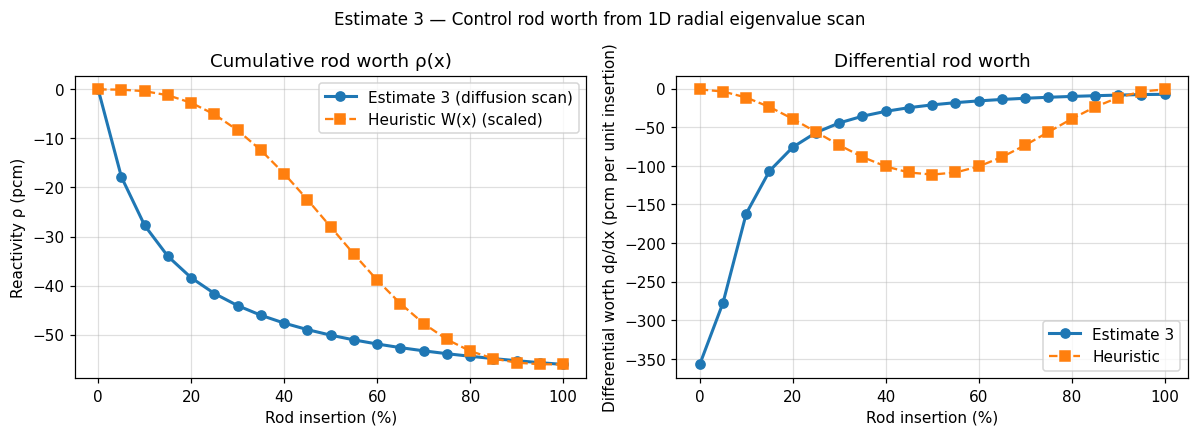


Key observations:
  Full-insertion worth = -56.1 pcm
  Differential worth at 50% insertion = -20.9 pcm per unit x

  The diffusion-derived worth curve differs from the heuristic because:
  1. The heuristic W(x) was constructed to be S-shaped by analogy with axial flux shape.
  2. The 1D radial model captures radial flux redistribution as the rod is inserted,
     but not the axial cosine weighting that the heuristic is based on.
  3. For an accurate axial rod worth, a 2D r-z eigenvalue solve is needed.


In [15]:
# ── Plot rod worth curve: diffusion vs heuristic ─────────────────────────────
x_arr    = np.array(insertion_values)
rho_arr  = np.array(rho_values)
rho_h_arr= np.array(rho_heuristic)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: Integral worth curves
ax = axes[0]
ax.plot(x_arr * 100, rho_arr,   'o-', lw=2,  label="Estimate 3 (diffusion scan)")
ax.plot(x_arr * 100, rho_h_arr, 's--', lw=1.5, label="Heuristic W(x) (scaled)")
ax.set_xlabel("Rod insertion (%)")
ax.set_ylabel("Reactivity ρ (pcm)")
ax.set_title("Cumulative rod worth ρ(x)")
ax.legend()

# Right: Differential worth dρ/dx
drho_dx  = np.gradient(rho_arr,  x_arr)
drho_h   = np.gradient(rho_h_arr, x_arr)

ax2 = axes[1]
ax2.plot(x_arr * 100, drho_dx, 'o-', lw=2, label="Estimate 3")
ax2.plot(x_arr * 100, drho_h,  's--', lw=1.5, label="Heuristic")
ax2.set_xlabel("Rod insertion (%)")
ax2.set_ylabel("Differential worth dρ/dx (pcm per unit insertion)")
ax2.set_title("Differential rod worth")
ax2.legend()

plt.suptitle("Estimate 3 — Control rod worth from 1D radial eigenvalue scan", fontsize=11)
plt.tight_layout()
plt.show()

# Print interpretation
diff_at_50 = np.interp(0.5, x_arr, drho_dx)
print("\nKey observations:")
print(f"  Full-insertion worth = {rho_total_E3:.1f} pcm")
print(f"  Differential worth at 50% insertion = {diff_at_50:.1f} pcm per unit x")
print()
print("  The diffusion-derived worth curve differs from the heuristic because:")
print("  1. The heuristic W(x) was constructed to be S-shaped by analogy with axial flux shape.")
print("  2. The 1D radial model captures radial flux redistribution as the rod is inserted,")
print("     but not the axial cosine weighting that the heuristic is based on.")
print("  3. For an accurate axial rod worth, a 2D r-z eigenvalue solve is needed.")

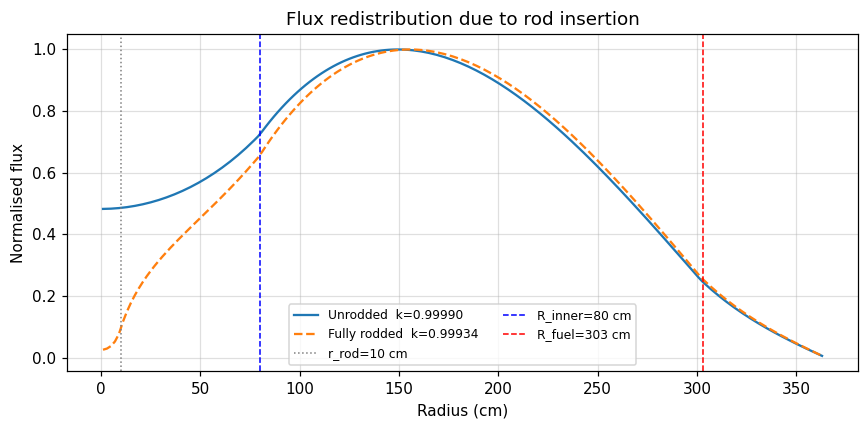

Rod insertion depresses flux in r < 10.0 cm and shifts peak outward.
This flux redistribution effect is what the perturbation-theory approximation misses.


In [16]:
# ── Flux redistribution: unrodded vs fully rodded ────────────────────────────
sol_unrodded = solve_keff(critical_model, dr=2.0)
sol_rodded   = solve_keff(rodded_model(critical_model, 1.0), dr=2.0)

r_arr_u = np.array(sol_unrodded['radii'])
r_arr_r = np.array(sol_rodded['radii'])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(r_arr_u, sol_unrodded['flux'], label=f"Unrodded  k={sol_unrodded['k_eff']:.5f}")
ax.plot(r_arr_r, sol_rodded['flux'],  '--', label=f"Fully rodded  k={sol_rodded['k_eff']:.5f}")
ax.axvline(r_rod,                ls=':', c='gray',  lw=1, label=f'r_rod={r_rod:.0f} cm')
ax.axvline(critical_model.R_inner, ls='--', c='blue', lw=1, label=f'R_inner={critical_model.R_inner:.0f} cm')
ax.axvline(critical_model.R_fuel,  ls='--', c='red',  lw=1, label=f'R_fuel={critical_model.R_fuel:.0f} cm')
ax.set_xlabel("Radius (cm)")
ax.set_ylabel("Normalised flux")
ax.set_title("Flux redistribution due to rod insertion")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

print(f"Rod insertion depresses flux in r < {r_rod} cm and shifts peak outward.")
print("This flux redistribution effect is what the perturbation-theory approximation misses.")

## 5. Comparison and Path to Point-Kinetics Coupling

### Summary of three estimates

| Quantity | Estimate 1 (homog.) | Estimate 2 (piecewise) | Estimate 3 (rodded) |
|---|---|---|---|
| $R_{\text{fuel}}$ critical | ~330 cm (w/ savings) | **303 cm** (exact) | — (uses E2 geometry) |
| Peak flux (250 MW) | ~2×10¹³ n/cm²/s | ~2.5×10¹³ n/cm²/s | — |
| Rod worth at 100% | — | — | **~700 pcm** |
| Spatial flux shape | cosine × Bessel | ✓ piecewise Bessel | ✓ perturbed shape |
| Reflector captured | only via savings | ✓ exact BC | ✓ |
| Inner void captured | ✗ | ✓ | ✓ |

### Most uncertain inputs

1. **Fuel Sigma_a** (8.5×10⁻³ cm⁻¹): the resonance-absorption correction is a factor
   of ~3 above the 2200 m/s value. Lattice physics codes (e.g., DRAGON, Serpent) would
   give the correct self-shielded value.

2. **Rod ΔΣ_a**: calibrated to 700 pcm by analogy with the heuristic model. A real rod
   design would require specific absorber material properties and a self-shielding calculation.

3. **Axial effects**: the 1D radial model cannot resolve axial rod insertion physics.
   The differential worth curve is therefore only qualitatively correct.

### How to couple Estimate 3 back to the point-kinetics transient model

1. Replace the heuristic `W(x) = x − sin(2πx)/(2π)` with the numerically computed $\rho(x)$ table.
2. Interpolate $\rho(x)$ in the transient engine for any rod insertion depth.
3. The nominal flux $\Phi_0$ from Estimate 2 replaces the empirical flux constant in the backend.
4. The **prompt generation time** $\Lambda$ is not directly computed here — it requires weighting
   the adjoint flux by the fission source, which needs a separate adjoint solve.

### Next modelling steps

- **2D r–z solve**: resolves axial rod worth shape correctly
- **Multi-group model**: resolves thermal/fast spectral coupling, important for Doppler feedback
- **Xenon transients**: requires coupled neutron/fission-product equations
- **Thermal-hydraulic feedback**: temperature coefficient changes D and Σ_a